In [1]:
# !pip install polars
# !pip install xlsxwriter

In [2]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-f')

# Import datasets


In [3]:
import polars as pl

general_information = pl.read_csv('data/general_information_bkp.csv', infer_schema_length=None, ignore_errors=True)
type_and_level = pl.read_csv('data/type_and_level_bk.csv', infer_schema_length=None, ignore_errors=True)
geographical_facilities = pl.read_csv('data/geographical_facilities_bkp.csv', infer_schema_length=None, ignore_errors=True)
buildings_and_library = pl.read_csv('data/buildings_and_library.csv', infer_schema_length=None, ignore_errors=True)
compliance1 = pl.read_csv('data/compliance_1_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance2 = pl.read_csv('data/compliance_2_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance3 = pl.read_csv('data/compliance_3_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance4 = pl.read_csv('data/compliance_4_bkp.csv', infer_schema_length=None, ignore_errors=True)
divisions = pl.read_csv('data/divisions_bkp.csv', infer_schema_length=None, ignore_errors=True)
districts = pl.read_csv('data/districts_bkp.csv', infer_schema_length=None, ignore_errors=True)
thanas = pl.read_csv('data/thanas_bkp.csv', infer_schema_length=None, ignore_errors=True)
pbgsi_institutions = pl.read_csv('data/pbgsi_7000_ins_bkp.csv', infer_schema_length=None, ignore_errors=True)
institute_type = pl.read_csv('configs/institution_type.csv', infer_schema_length=None, ignore_errors=True)
student_type = pl.read_csv('configs/student_types.csv', infer_schema_length=None, ignore_errors=True)
divisions = pl.read_csv('data/divisions_bkp.csv', infer_schema_length=None, ignore_errors=True)
districts = pl.read_csv('data/districts_bkp.csv', infer_schema_length=None, ignore_errors=True)
thanas = pl.read_csv('data/thanas_bkp.csv', infer_schema_length=None, ignore_errors=True)
approval_status = pl.read_csv('configs/approval_status.csv', infer_schema_length=None, ignore_errors=True)
boards = pl.read_csv('configs/boards.csv', infer_schema_length=None, ignore_errors=True)
boundary_types = pl.read_csv('configs/boundary_type.csv', infer_schema_length=None, ignore_errors=True)
emis_submission_types = pl.read_csv('configs/emis_submission_types.csv', infer_schema_length=None, ignore_errors=True)
fiscal_years = pl.read_csv('configs/fiscal_years.csv', infer_schema_length=None, ignore_errors=True)
geographical_location_types = pl.read_csv('configs/geographical_locations_type.csv', infer_schema_length=None, ignore_errors=True)
highest_levels = pl.read_csv('configs/higest_levels.csv',infer_schema_length=None, ignore_errors=True)
management_type = pl.read_csv('configs/management_types.csv', infer_schema_length=None, ignore_errors=True)
mpo_status = pl.read_csv('configs/mpo_status.csv', infer_schema_length=None, ignore_errors=True)
ownership_types = pl.read_csv('configs/ownership_type.csv', infer_schema_length=None, ignore_errors=True)
pass_rate_types = pl.read_csv('configs/pass_rate_type.csv', infer_schema_length=None, ignore_errors=True)
sexual_harassment_committee_activity_type = pl.read_csv('configs/sexual_harassment_committee_activity_type.csv', infer_schema_length=None, ignore_errors=True)
students_attendance_types = pl.read_csv('configs/students_attendance_type.csv', infer_schema_length=None, ignore_errors=True)
teachers_attendance_types = pl.read_csv('configs/teachers_attendance_type.csv', infer_schema_length=None, ignore_errors=True)
technical_types = pl.read_csv('configs/technical_type.csv', infer_schema_length=None, ignore_errors=True)
ward_type = pl.read_csv('configs/ward_type.csv', infer_schema_length=None, ignore_errors=True)

# Generate Column Names

In [4]:
df_vars = {
    name: val
    for name, val  in globals().items()
    if isinstance(val, (pl.DataFrame, pl.LazyFrame))
}

In [5]:
from pathlib import Path

out_dir = Path.cwd() / "generate"
out_dir.mkdir(parents=True, exist_ok=True)

In [6]:
for name, val  in df_vars.items():
    with open("generate/" + name +".py", "w") as f:
        for col in val.columns:
            safe_col = col.strip().replace(" ", "_").replace("-","_").replace("[","").replace("]","")
            f.write(f'{safe_col.upper()}="{col}"\n')

In [7]:
import importlib

def update_columns(dataframe_name: str):
    df_vars = {
    name: val
    for name, val  in globals().items()
    if isinstance(val, (pl.DataFrame, pl.LazyFrame))
    }
    for name, val  in df_vars.items():
        if name == dataframe_name:
            print('found match')
            with open("generate/" + name +".py", "w") as f:
                for col in val.columns:
                    safe_col = col.strip().replace(" ", "_").replace("-","_").replace("[","").replace("]","")
                    f.write(f'{safe_col.upper()}="{col}"\n')
            print('column names updated')
            module = importlib.import_module('generate.'+dataframe_name)
            importlib.reload(module)

Consider only submitted institutions

In [8]:
from generate.general_information import SUBMITTED

general_information = general_information.filter(pl.col(SUBMITTED) == 1)

Join general information with Type and Level, Geographical Facilities, Compliance1, Compliance2, Compliance3, Compliance4

In [9]:
general_information = general_information.join(type_and_level, left_on=general_information['eiin'].name, right_on=type_and_level['eiin'].name, how="inner", suffix='_type_and_level')
general_information = general_information.join(geographical_facilities, left_on=general_information['eiin'].name, right_on=geographical_facilities['eiin'].name, how="inner", suffix='_geographical_facilities')
general_information = general_information.join(compliance1, left_on=general_information['eiin'].name, right_on=compliance1['eiin'].name, how='inner', suffix='_compliance1')
general_information = general_information.join(compliance2, left_on=general_information['eiin'].name, right_on=compliance2['eiin'].name, how='inner', suffix='_compliance2')
general_information = general_information.join(compliance3, left_on=general_information['eiin'].name, right_on=compliance3['eiin'].name, how='left', suffix='_compliance3')
general_information = general_information.join(compliance4, left_on=general_information['eiin'].name, right_on=compliance4['eiin'].name, how='inner', suffix='_compliance4')

Update the generated column names of general_information

In [10]:
update_columns('general_information')

found match
column names updated


Filter only pubgsi submitted institutions

In [11]:
from generate.general_information import PBGSI_SCHEME

general_information = general_information.filter(pl.col(PBGSI_SCHEME) == True)

Join general_information with institute_type, student_type, divisions, districts, thanas, geographical_location_types

In [12]:
general_information = general_information.join(institute_type, left_on=general_information['institution_type'].name, right_on=institute_type['institute_type_id'].name, how='inner', suffix='_institution_type')
general_information = general_information.join(student_type, left_on=general_information['student_type'].name, right_on=student_type['student_type_id'].name, how='inner', suffix='_student_type')
general_information = general_information.join(divisions, left_on=general_information['address_division'].name, right_on=divisions['division_id'].name, how='inner', suffix='_division')
general_information = general_information.join(districts, left_on=general_information['address_district'].name, right_on=districts['district_id'].name, how='inner', suffix='_district')
general_information = general_information.join(thanas, left_on=general_information['address_thana'].name, right_on=thanas['thana_id'].name, how='inner', suffix='_thana')
general_information = general_information.join(geographical_location_types, left_on=geographical_facilities['geographical_position'].name, right_on=geographical_location_types['geographical_location_id'].name, how='inner', suffix='_geographical_location_type')

In [13]:
update_columns('general_information')

found match
column names updated


In [14]:
general_information.head(5)

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,ninth_grade_books_issued_count,ninth_grade_books_received,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """
218067,"""রাঙ্গামূলারকান্দি হাজী আব্দুল্…","""RANGAMULAR KANDI HAZI ABDULLAH…","""RANGAMULAR KANDI""","""Rangamular kandi""","""Shriangan""","""7804""",null,null,92,16,4,"""01309108676""","""108676_20250811_055124.jpg""",23.442474,89.708453,"""OWN""",false,true,true,true,true,null,"""108676""",null,9.0,4.217729,null,1,"""01-01-1965""","""7""",null,null,"""Dadpur""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""স

In [15]:
general_information['institute_type_name_en'].head()

institute_type_name_en
str
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""MADRASHA"""
"""SCHOOL"""


Merge college and school & college for the purpose of the report

In [16]:
# first we copy the columns to new columns
general_information = general_information.with_columns([
    pl.col('institution_type').alias('generalized_institution_type_id'),
    pl.col('institute_type_name_en').alias('generalized_institution_type_name_en')
])

In [17]:
update_columns('general_information')

found match
column names updated


In [18]:
general_information.head()

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name,generalized_institution_type_id,generalized_institution_type_name_en
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str,i64,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল""",1,"""SCHOOL"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """,1,"""SCHOOL"""
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """,1,"""SCHOOL"""
218067,"""রাঙ্গামূলারকান্দি হাজী আব্দুল্…","""RANGAMULAR KANDI HAZI ABDULLAH…","""RANGAMULAR KANDI""","""Rangamular kandi""","""Shriangan""","""7804""",null,null,92,16,4,"""01309108676""","""108676_20250811_055124.jpg""",23.442474,89.708453,"""OWN""",false,true,true,true,true,null,"""108676""",null,9.0,4.217729,null,1,"""01-01-1965""","""7""",null,null,"""Dadpur""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","

In [19]:

# when we get the college type, we change the type to school & college

condition = pl.col(general_information['generalized_institution_type_id'].name)==3

general_information = general_information.with_columns([
    pl.when(condition)
    .then(pl.lit(2))
    .otherwise(pl.col(general_information['generalized_institution_type_id'].name))
    .alias('generalized_institution_type_id'),
    
    pl.when(condition)
    .then(pl.lit('SCHOOL AND COLLEGE'))
    .otherwise(pl.col(general_information['generalized_institution_type_name_en'].name))
    .alias('generalized_institution_type_name_en')
])

In [20]:
general_information.head()

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name,generalized_institution_type_id,generalized_institution_type_name_en
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str,i64,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল""",1,"""SCHOOL"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """,1,"""SCHOOL"""
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """,1,"""SCHOOL"""
218067,"""রাঙ্গামূলারকান্দি হাজী আব্দুল্…","""RANGAMULAR KANDI HAZI ABDULLAH…","""RANGAMULAR KANDI""","""Rangamular kandi""","""Shriangan""","""7804""",null,null,92,16,4,"""01309108676""","""108676_20250811_055124.jpg""",23.442474,89.708453,"""OWN""",false,true,true,true,true,null,"""108676""",null,9.0,4.217729,null,1,"""01-01-1965""","""7""",null,null,"""Dadpur""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","

In [21]:
student_type.head()

student_type_id,student_type_name,student_type_name_en
i64,str,str
1,"""ছেলে""","""Boy"""
2,"""মেয়ে""","""Girl"""
3,"""সহশিক্ষা""","""Co-education"""


## Table 1. Number of secondary institutions havign management accoutability grant by type of institution and gender composition
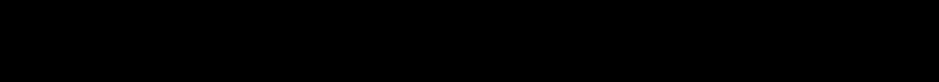
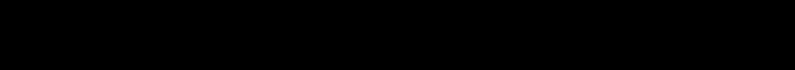
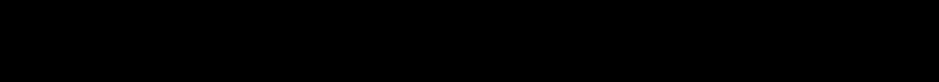

In [22]:
report1 = (
    general_information.lazy()
    .group_by(pl.col('generalized_institution_type_name_en').alias('institution_type'))
    .agg([
         pl.len().alias('total'),
         (pl.col('student_type')==1).sum().alias('total_boys'),
         (pl.col('student_type')==2).sum().alias('total_girls'),
         (pl.col('student_type')==3).sum().alias('co-education')
    ])
)

report1_df = report1.collect()
report1_df.head(100)

institution_type,total,total_boys,total_girls,co-education
str,u32,u32,u32,u32
"""MADRASHA""",2046,7,178,1861
"""SCHOOL""",5631,63,801,4767
"""SCHOOL AND COLLEGE""",627,2,90,535
"""TECHNICAL AND VOCATIONAL""",28,0,1,27
"""QAOMI MADRASHA""",16,7,7,2


In [23]:
report1_df.write_excel('output/table1.xlsx')

## Table 2. Distribution of secondary institutions having Management Accountability Grant by Division and type of institution

In [24]:
institute_type.head(10)

institute_type_id,institute_type_name,institute_type_name_en
i64,str,str
1,"""স্কুল""","""SCHOOL"""
2,"""স্কুল এন্ড কলেজ""","""SCHOOL AND COLLEGE"""
3,"""কলেজ""","""COLLEGE"""
4,"""মাদ্রাসা""","""MADRASHA"""
5,"""কওমী মাদ্রাসা""","""QAOMI MADRASHA"""
6,"""কারিগরি ও ভোকেশনাল""","""TECHNICAL AND VOCATIONAL"""


In [25]:
from generate.general_information import DIVISION_NAME, INSTITUTION_TYPE
institution_type_school = 1
institution_type_school_and_college = 2
institution_type_madrasha = 4

report2 = (
    general_information.lazy()
    .group_by(pl.col(DIVISION_NAME).alias("Division"))
    .agg([
      (pl.col(INSTITUTION_TYPE)== institution_type_school).sum().alias('Secondary School'),
      (pl.col(INSTITUTION_TYPE)==institution_type_school_and_college).sum().alias('School & College'),
      (pl.col(INSTITUTION_TYPE)== institution_type_madrasha).sum().alias('Madrasha')
    ])
)

report2_df = report2.collect()
report2_df.head(10)

Division,Secondary School,School & College,Madrasha
str,u32,u32,u32
"""Rangpur""",719,67,226
"""Chattogram""",1081,90,395
"""Rajshahi""",650,59,300
"""Khulna""",763,48,204
"""Dhaka""",1114,145,334
"""Mymensingh""",359,30,144
"""Barishal""",628,42,336
"""Sylhet""",317,81,107


Add percentage

In [26]:
report2_df = report2_df.with_columns([
    ((pl.col('Secondary School')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('school percentage'),
    ((pl.col('School & College')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('school & college percentage'),
    ((pl.col('Madrasha')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('madrasha percentage')
])

In [27]:
report2_df.head(10)

Division,Secondary School,School & College,Madrasha,school percentage,school & college percentage,madrasha percentage
str,u32,u32,u32,f64,f64,f64
"""Rangpur""",719,67,226,71.05,6.62,22.33
"""Chattogram""",1081,90,395,69.03,5.75,25.22
"""Rajshahi""",650,59,300,64.42,5.85,29.73
"""Khulna""",763,48,204,75.17,4.73,20.1
"""Dhaka""",1114,145,334,69.93,9.1,20.97
"""Mymensingh""",359,30,144,67.35,5.63,27.02
"""Barishal""",628,42,336,62.43,4.17,33.4
"""Sylhet""",317,81,107,62.77,16.04,21.19


In [28]:
report2_df = report2_df.sort('Division', descending=False)

In [29]:
report2_df.head(10)

Division,Secondary School,School & College,Madrasha,school percentage,school & college percentage,madrasha percentage
str,u32,u32,u32,f64,f64,f64
"""Barishal""",628,42,336,62.43,4.17,33.4
"""Chattogram""",1081,90,395,69.03,5.75,25.22
"""Dhaka""",1114,145,334,69.93,9.1,20.97
"""Khulna""",763,48,204,75.17,4.73,20.1
"""Mymensingh""",359,30,144,67.35,5.63,27.02
"""Rajshahi""",650,59,300,64.42,5.85,29.73
"""Rangpur""",719,67,226,71.05,6.62,22.33
"""Sylhet""",317,81,107,62.77,16.04,21.19


In [30]:
report2_df = report2_df.select(['Division', 'Secondary School', 'school percentage', 'School & College', 'school & college percentage', 'Madrasha', 'madrasha percentage'])

In [31]:
report2_df.head(10)

Division,Secondary School,school percentage,School & College,school & college percentage,Madrasha,madrasha percentage
str,u32,f64,u32,f64,u32,f64
"""Barishal""",628,62.43,42,4.17,336,33.4
"""Chattogram""",1081,69.03,90,5.75,395,25.22
"""Dhaka""",1114,69.93,145,9.1,334,20.97
"""Khulna""",763,75.17,48,4.73,204,20.1
"""Mymensingh""",359,67.35,30,5.63,144,27.02
"""Rajshahi""",650,64.42,59,5.85,300,29.73
"""Rangpur""",719,71.05,67,6.62,226,22.33
"""Sylhet""",317,62.77,81,16.04,107,21.19


In [32]:
report2_df.write_excel('output/table2.xlsx')

## Table 3. Number of Secondary Institutions received Management Accountability Grant having Toilet Facilities for students by type of institution

In [33]:
from generate.general_information import INSTITUTE_TYPE_NAME_EN, HAS_STUDENT_TOILET, TOTAL_TOILET_FOR_BOYS, TOTAL_TOILET_FOR_GIRLS, TOTAL_TOILET_FOR_SPECIAL_NEEDS

report3 = (
    general_information.lazy()
    .group_by(pl.col(INSTITUTE_TYPE_NAME_EN).alias('institution_type'))
    .agg([
        (pl.col(HAS_STUDENT_TOILET)==1).sum().alias('toilet_yes'),
        (pl.col(HAS_STUDENT_TOILET)==0).sum().alias('toilet_no'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)==1).sum().alias('boys_1'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)==2).sum().alias('boys_2'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)>2).sum().alias('boys_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_BOYS).is_null() | pl.col(TOTAL_TOILET_FOR_BOYS)==0).sum().alias('boys_none'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)==1).sum().alias('girls_1'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)==2).sum().alias('girls_2'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)>2).sum().alias('girls_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS).is_null() | pl.col(TOTAL_TOILET_FOR_GIRLS)==0).sum().alias('girls_none'),
        (pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS)>=1).sum().alias('special_needs_toilet'),
        (pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS).is_null() | pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS)==0).sum().alias('special_needs_none')
    ])
)

report3_df = report3.collect()
report3_df.head(100)

institution_type,toilet_yes,toilet_no,boys_1,boys_2,boys_2_plus,boys_none,girls_1,girls_2,girls_2_plus,girls_none,special_needs_toilet,special_needs_none
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""TECHNICAL AND VOCATIONAL""",27,1,11,9,5,2,9,10,7,1,6,21
"""SCHOOL AND COLLEGE""",561,1,38,75,360,88,43,86,428,4,183,378
"""SCHOOL""",5591,40,845,1247,2653,850,912,1282,3305,96,1686,3908
"""COLLEGE""",65,0,18,13,28,6,17,18,29,1,14,51
"""QAOMI MADRASHA""",13,3,2,0,5,6,2,2,4,5,1,12
"""MADRASHA""",2033,13,522,515,804,195,572,601,843,20,505,1530


In [34]:
report3_df.write_excel('output/table3.xlsx')

## Table 4. Number of Secondary Institutions received Management Accountability Grant having Toilet Facilities for teachers by type of institution

In [35]:
from generate.general_information import INSTITUTE_TYPE_NAME_EN, HAS_TEACHER_TOILET, TOTAL_TOILET_FOR_MALE_TEACHERS, TOTAL_TOILET_FOR_FEMALE_TEACHERS, TOTAL_TOILET_FOR_COMMONS

report4 = (
    general_information.lazy()
    .group_by(pl.col(INSTITUTE_TYPE_NAME_EN).alias('institution_type'))
    .agg([
        (pl.col(HAS_TEACHER_TOILET)==1).sum().alias('toilet_yes'),
        (pl.col(HAS_TEACHER_TOILET)==0).sum().alias('toilet_no'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)==1).sum().alias('male_1'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)>=2).sum().alias('male_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS).is_null() | pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)==0).sum().alias('male_none'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)==1).sum().alias('female_1'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)>=2).sum().alias('female_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS).is_null() | pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)==0 ).sum().alias('female_none'),
        (pl.col(TOTAL_TOILET_FOR_COMMONS)==1).sum().alias('common_1'),
        (pl.col(TOTAL_TOILET_FOR_COMMONS)>1).sum().alias('common_plus')
    ])
)

report4_df = report4.collect()

report4_df.head(10)

institution_type,toilet_yes,toilet_no,male_1,male_2_plus,male_none,female_1,female_2_plus,female_none,common_1,common_plus
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL""",5566,65,2324,2306,944,3140,1227,1207,2267,793
"""TECHNICAL AND VOCATIONAL""",26,2,17,8,1,20,1,5,10,1
"""QAOMI MADRASHA""",12,4,7,5,0,4,1,7,1,0
"""SCHOOL AND COLLEGE""",561,1,149,356,56,273,218,70,196,110
"""COLLEGE""",65,0,23,35,7,31,25,9,26,18
"""MADRASHA""",1999,47,932,842,233,1202,409,395,689,287


In [36]:
report4_df.write_excel('output/table4.xlsx')

## Table 5. Number of Secondary Institutions received Management Accountability Grant having wash-block/wash-room by type of institution

In [37]:
from generate.general_information import INSTITUTE_TYPE_NAME_EN, HAS_WASH_BLOCK, TOTAL_WASH_BLOCK_FOR_BOYS, TOTAL_WASH_BLOCK_FOR_GIRLS, TOTAL_WASH_BLOCK_FOR_MALE_TEACHERS, TOTAL_WASH_BLOCK_FOR_FEMALE_TEACHERS, TOTAL_WASH_BLOCK_FOR_GIRLS_WITH_NAPKIN_FACILITY, TOTAL_WASH_BLOCK_FOR_COMMONS

report5 = (
    general_information.lazy()
    .group_by(pl.col(INSTITUTE_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(HAS_WASH_BLOCK)==1).sum().alias('wash_block_yes'),
        (pl.col(HAS_WASH_BLOCK)==0).sum().alias('wash_block_no'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_MALE_TEACHERS)>0).sum().alias('male_teacher'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_FEMALE_TEACHERS)>0).sum().alias('female_teacher'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_BOYS)>0).sum().alias('boys student'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_GIRLS)>0).sum().alias('girls student (general)'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_GIRLS_WITH_NAPKIN_FACILITY)>0).sum().alias('girls student (with napkin)'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_COMMONS)>0).sum().alias('for everyone')
    ])
)

report5_df = report5.collect()
report5_df.head()

institution type,wash_block_yes,wash_block_no,male_teacher,female_teacher,boys student,girls student (general),girls student (with napkin),for everyone
str,u32,u32,u32,u32,u32,u32,u32,u32
"""TECHNICAL AND VOCATIONAL""",15,13,11,10,10,11,5,11
"""COLLEGE""",35,30,32,27,23,25,17,15
"""SCHOOL AND COLLEGE""",390,172,271,259,237,305,211,159
"""MADRASHA""",1045,1001,752,710,623,722,399,445
"""QAOMI MADRASHA""",2,14,2,1,0,0,0,1


In [38]:
report5_df.write_excel('output/table5.xlsx')

## Table 6. Number of Secondary Institutions received Management Accountability Grant having common room and separate common room by type of institution

In [39]:
from generate.general_information import HAS_COMMON_ROOM, TOTAL_COMMON_ROOM_FOR_BOYS, TOTAL_COMMON_ROOM_FOR_GIRLS, INSTITUTE_TYPE_NAME_EN

report6 = (
    general_information.lazy()
    .group_by(pl.col(INSTITUTE_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(HAS_COMMON_ROOM)==1).sum().alias('common_room_yes'),
        (pl.col(HAS_COMMON_ROOM)==0).sum().alias('common_room_no'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_BOYS)==1).sum().alias('boys_1'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_BOYS)>1).sum().alias('boys_1_plus'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_BOYS).is_null() | pl.col(TOTAL_COMMON_ROOM_FOR_BOYS)==0).sum().alias('boys_none'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS)==1).sum().alias('girls_1'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS)>1).sum().alias('girls_2_plus'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS).is_null() | pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS)==0).sum().alias('girls_none')
    ])
)

report6_df = report6.collect()
report6_df.head(10)

institution type,common_room_yes,common_room_no,boys_1,boys_1_plus,boys_none,girls_1,girls_2_plus,girls_none
str,u32,u32,u32,u32,u32,u32,u32,u32
"""TECHNICAL AND VOCATIONAL""",19,9,6,1,12,17,0,2
"""MADRASHA""",1583,463,382,14,1206,1457,87,52
"""COLLEGE""",54,11,28,1,25,50,4,0
"""QAOMI MADRASHA""",5,11,2,1,2,1,0,3
"""SCHOOL AND COLLEGE""",385,177,116,8,272,320,50,22
"""SCHOOL""",3621,2010,881,29,2802,3213,269,211


In [40]:
report6_df.write_excel('output/table6.xlsx')

## Table 7. Number of Secondary Institutions received Management Accountability Grant having functional activities by type of institution

In [41]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_PTA, CONDUCTS_CLEANING_PROGRAM, CONDUCTS_ASSEMBLY, NATIONAL_DAYS_CELEBRATED

report7 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institute type'))
    .agg([
        pl.len().alias('total institution'),
        (pl.col(HAS_PTA)==1).sum().alias('effective pta'),
        (pl.col(CONDUCTS_CLEANING_PROGRAM)==1).sum().alias('cleaniness conducted'),
        (pl.col(CONDUCTS_ASSEMBLY)==1).sum().alias('regular assembly'),
        (pl.col(NATIONAL_DAYS_CELEBRATED)==1).sum().alias('observed national days')
    ])
)

report7_df = report7.collect()

report7_df = report7_df.with_columns(
    (((pl.col('effective pta')/ pl.col('total institution'))) * 100).round(2).alias('pta %'),
    (((pl.col('cleaniness conducted')/ pl.col('total institution'))) * 100).round(2).alias('cleaniness %'),
    (((pl.col('regular assembly')/ pl.col('total institution'))) * 100).round(2).alias('assembly %'),
    (((pl.col('observed national days')/ pl.col('total institution'))) * 100).round(2).alias('national %')
)

report7_df = report7_df.select(['institute type', 'total institution', 'effective pta', 'pta %', 'cleaniness conducted', 'cleaniness %', 'regular assembly', 'assembly %', 'observed national days', 'national %'])

report7_df.head(10)

institute type,total institution,effective pta,pta %,cleaniness conducted,cleaniness %,regular assembly,assembly %,observed national days,national %
str,u32,u32,f64,u32,f64,u32,f64,u32,f64
"""SCHOOL""",5631,4861,86.33,5589,99.25,5616,99.73,5616,99.73
"""SCHOOL AND COLLEGE""",627,518,82.62,623,99.36,615,98.09,625,99.68
"""MADRASHA""",2046,1659,81.09,2028,99.12,2028,99.12,2032,99.32
"""QAOMI MADRASHA""",16,5,31.25,14,87.5,11,68.75,13,81.25
"""TECHNICAL AND VOCATIONAL""",28,16,57.14,27,96.43,25,89.29,27,96.43


In [42]:
report7_df.write_excel('output/table7.xlsx')

## Table 8. Number of Secondary Institutions received Management Accountability Grant having facilities by type of institution

In [43]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_FAST_AID_BOX, HAS_PLAYGROUND, HAS_SHAHID_MINAR, HAS_RAMP_FOR_DISABLED

result8 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('total institution'),
        (pl.col(HAS_FAST_AID_BOX)==1).sum().alias('first aid box'),
        (pl.col(HAS_PLAYGROUND)==1).sum().alias('playground'),
        (pl.col(HAS_SHAHID_MINAR)==1).sum().alias('shahid minar'),
        (pl.col(HAS_RAMP_FOR_DISABLED)==1).sum().alias('ramp')
    ])
)

result8_df = result8.collect()

result8_df = result8_df.with_columns([
    ((pl.col('first aid box')/pl.col('total institution'))* 100).round(2).alias('first aid box %'),
    ((pl.col('playground')/pl.col('total institution'))* 100).round(2).alias('playground %'),
    ((pl.col('shahid minar')/pl.col('total institution'))* 100).round(2).alias('shahid minar %'),
    ((pl.col('ramp')/pl.col('total institution'))* 100).round(2).alias('ramp %'),
])

result8_df = result8_df.select(['institution type', 'total institution', 'first aid box', 'first aid box %', 'playground', 'playground %', 'shahid minar', 'shahid minar %', 'ramp', 'ramp %'])

result8_df.head(10)

institution type,total institution,first aid box,first aid box %,playground,playground %,shahid minar,shahid minar %,ramp,ramp %
str,u32,u32,f64,u32,f64,u32,f64,u32,f64
"""SCHOOL""",5631,4928,87.52,5458,96.93,4235,75.21,3814,67.73
"""TECHNICAL AND VOCATIONAL""",28,21,75.0,26,92.86,10,35.71,10,35.71
"""SCHOOL AND COLLEGE""",627,549,87.56,603,96.17,489,77.99,389,62.04
"""MADRASHA""",2046,1477,72.19,1942,94.92,293,14.32,996,48.68
"""QAOMI MADRASHA""",16,2,12.5,10,62.5,2,12.5,0,0.0


In [44]:
result8_df.write_excel('output/table8.xlsx')

## Table 9. Number of Secondary Institutions received Management Accountability Grant having different co-curricular activities by type of institution

In [45]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, CONDUCTS_CO_CURRICULAR_ACTIVITIES, ANNUAL_CULTURAL_PROGRAM, BNCC, SCOUT, SCOUT_GIRLS_GUIDE_ROVER, ROVER, ANNUAL_SPORTS, DEBATE_COMPETITIONS

result9 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(CONDUCTS_CO_CURRICULAR_ACTIVITIES)==1).sum().alias('co-curricular yes'),
        (pl.col(CONDUCTS_CO_CURRICULAR_ACTIVITIES)==0).sum().alias('co-curricular no'),
        (pl.col(ANNUAL_CULTURAL_PROGRAM)==1).sum().alias('annual cultural program'),
        (pl.col(BNCC)==1).sum().alias('bncc'),
        (pl.col(SCOUT)==1).sum().alias('scout'),
        (pl.col(SCOUT_GIRLS_GUIDE_ROVER)==1).sum().alias('girls guide'),
        (pl.col(ROVER)==1).sum().alias('rover'),
        (pl.col(ANNUAL_SPORTS)==1).sum().alias('annual sports'),
        (pl.col(DEBATE_COMPETITIONS)==1).sum().alias('debate')
    ])
)


result9_df = result9.collect()
result9_df.head()

institution type,co-curricular yes,co-curricular no,annual cultural program,bncc,scout,girls guide,rover,annual sports,debate
str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL AND COLLEGE""",616,11,601,62,448,531,103,605,602
"""TECHNICAL AND VOCATIONAL""",27,1,26,2,9,9,1,27,24
"""QAOMI MADRASHA""",10,6,10,0,0,0,0,4,11
"""SCHOOL""",5591,40,5452,223,4124,4791,178,5520,5425
"""MADRASHA""",2008,38,1941,76,1041,1275,177,1947,1907


In [46]:
result9_df.write_excel('output/table9.xlsx')

## Table 10. Number of Secondary Institutions received Management Accountability Grant having different co-curricular activities by type of institution

In [47]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, CONDUCTS_AWARENESS_PROGRAMS, BAALYABIBAHA_RODH, EVTIJING_PROTIRODH, MADOK_BIRODHI_KARYAKRAM, NIRAPOD_SHOROK_CHAI_KARYAKRAM, COMMUNITY_INTERACTION, ACID_NIKKHEP_PROTIRUDH, BOOLING_PROTIRUDH

result10 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(CONDUCTS_AWARENESS_PROGRAMS)==1).sum().alias('awareness_yes'),
        (pl.col(CONDUCTS_AWARENESS_PROGRAMS)==0).sum().alias('awareness_no'),
        (pl.col(BAALYABIBAHA_RODH)==1).sum().alias('child marriage prevention'),
        (pl.col(EVTIJING_PROTIRODH)==1).sum().alias('eve teasing prevention'),
        (pl.col(MADOK_BIRODHI_KARYAKRAM)==1).sum().alias('anti drug'),
        (pl.col(NIRAPOD_SHOROK_CHAI_KARYAKRAM)==1).sum().alias('safe road'),
        (pl.col(COMMUNITY_INTERACTION)==1).sum().alias('community interaction'),
        (pl.col(ACID_NIKKHEP_PROTIRUDH)==1).sum().alias('acid prevention'),
        (pl.col(BOOLING_PROTIRUDH)==1).sum().alias('bullying prevention')
    ])
)

result10_df = result10.collect()
result10_df.head()

institution type,awareness_yes,awareness_no,child marriage prevention,eve teasing prevention,anti drug,safe road,community interaction,acid prevention,bullying prevention
str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""MADRASHA""",2040,6,2029,2000,1954,1200,370,1251,902
"""TECHNICAL AND VOCATIONAL""",27,1,27,28,27,18,3,21,14
"""QAOMI MADRASHA""",14,2,12,9,10,10,0,7,3
"""SCHOOL AND COLLEGE""",625,2,613,609,612,421,188,401,365
"""SCHOOL""",5617,14,5567,5487,5395,3223,1377,3510,3133


In [48]:
result10_df.write_excel('output/table10.xlsx')

## Table 11. Number of Secondary Institutions received Management Accountability Grant having electricity through different sources by type of institution

In [49]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_ELECTRICITY, NATIONAL_GRID, GENERATOR, SOLAR

result11 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(HAS_ELECTRICITY)==1).sum().alias('electricity_yes'),
        (pl.col(HAS_ELECTRICITY)==0).sum().alias('electricity_no'),
        (pl.col(NATIONAL_GRID)==1).sum().alias('national grid'),
        (pl.col(GENERATOR)==1).sum().alias('generator'),
        (pl.col(SOLAR)==1).sum().alias('solar')
    ])
)

result11_df = result11.collect()
result11_df.head(10)

institution type,electricity_yes,electricity_no,national grid,generator,solar
str,u32,u32,u32,u32,u32
"""QAOMI MADRASHA""",16,0,16,3,2
"""MADRASHA""",2040,6,2034,44,536
"""SCHOOL AND COLLEGE""",626,1,624,60,146
"""TECHNICAL AND VOCATIONAL""",28,0,28,1,6
"""SCHOOL""",5623,8,5596,204,1205


In [50]:
result11_df.write_excel('output/table11.xlsx')

## Table 12: Number of Secondary Institutions Having Management Accountability Grant and refunded the grant by Type of institution

In [51]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, PBGSI_SCHEME, WAS_RETURNED

result12 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('total institution'),
        (pl.col(PBGSI_SCHEME)==True).sum().alias('received grant'),
        (pl.col(WAS_RETURNED)==1).sum().alias('refunded grant')
    ])
)

result12_df = result12.collect()

result12_df = result12_df.with_columns([
    ((pl.col('received grant')/pl.col('total institution'))*100).round(2).alias('received grant %'),
    ((pl.col('refunded grant')/pl.col('total institution'))*100).round(2).alias('refunded grant %')
])

result12_df = result12_df.select(['institution type', 'total institution', 'received grant', 'received grant %', 'refunded grant', 'refunded grant %'])

result12_df.head(10)

institution type,total institution,received grant,received grant %,refunded grant,refunded grant %
str,u32,u32,f64,u32,f64
"""QAOMI MADRASHA""",16,16,100.0,2,12.5
"""MADRASHA""",2046,2046,100.0,43,2.1
"""SCHOOL""",5631,5631,100.0,166,2.95
"""TECHNICAL AND VOCATIONAL""",28,28,100.0,0,0.0
"""SCHOOL AND COLLEGE""",627,627,100.0,30,4.78


In [52]:
result12_df.write_excel('output/table12.xlsx')

# Compliance Calculation

# PBGSI Compliance Evaluation Criteria (as per operational manual)

In [53]:
from generate.general_information import FUNCTIONAL_SMC_MMC_GB, MEETINGS_2022, MEETINGS_2023, RESPONSIBILITIES_COMPLETED, ANNUAL_BUDGET_APPROVED, PUBLIC_PARTICIPATION,ACADEMIC_INITIATIVES, COMMITTEE_REGULAR_WORK 
from generate.general_information import SEXUAL_HARASSMENT_COMMITTEE, COMMITTEE_REGULAR_WORK, EIMS_SUBMISSION_TIMELY,SSC_2021_PASSED_STUDENTS, SSC_2021_TOTAL_STUDENTS, SSC_2022_TOTAL_STUDENTS, SSC_2022_PASSED_STUDENTS, SSC_BOARD_2021_PASS_RATE, SSC_BOARD_2022_PASS_RATE
from generate.general_information import STUDENTS_ATTENDANCE_2022, TEACHERS_ATTENDANCE_2022, REPORT_CARD_REGULARLY_STORED, REPORT_CARD_PUBLISHED_IN_WEB, REPORT_CARD_DISPLAYED, REPORT_CARD_NOT_REGULARLY_STORED
from generate.general_information import SEPARATE_WASHROOMS, COMMON_ROOM, FIRST_AID, CLEAN_ENVIRONMENT, REGULAR_CLEANING_PLAN, STUDENT_PARTICIPATION_IN_CLEANING
from generate.general_information import  MARTYRS_MEMORIAL, SEPARATE_LIBRARY, LIBERATION_WAR_CORNER, PLAYGROUND
from generate.general_information import NATIONAL_ANTHEM_WITH_PARADE, INDOOR_NATIONAL_ANTHEM, NATIONAL_DAYS_CELEBRATED, PROPER_FLAG_HOISTING
from generate.general_information import  ANNUAL_CULTURAL_PROGRAM, BNCC_COMPLIANCE2, SCOUT_GIRLS_GUIDE_ROVER, SPORTS_COMPETITIONS, DEBATE_COMPETITIONS
from generate.general_information import ANTI_SMOKING_CAMPAIGN, ANTI_TERRORISM_CAMPAIGN, ANTI_CHILD_MARRIAGE_CAMPAIGN


general_information = general_information.with_columns(
    pl.col(MEETINGS_2022).fill_null(0).alias(MEETINGS_2022),
    pl.col(MEETINGS_2023).fill_null(0).alias(MEETINGS_2023),
    ((pl.col(SSC_2021_PASSED_STUDENTS)/pl.col(SSC_2021_TOTAL_STUDENTS))* 100).round(2).alias('ssc_pass_rate_2021'),
    ((pl.col(SSC_2022_PASSED_STUDENTS)/pl.col(SSC_2022_TOTAL_STUDENTS))* 100).round(2).alias('ssc_pass_rate_2022'),
)

general_information = general_information.with_columns([
    ((pl.col(MEETINGS_2022) + pl.col(MEETINGS_2023))/2).alias('annual_meetings_avg'),
    ((pl.col('ssc_pass_rate_2021') + pl.col('ssc_pass_rate_2022'))/2).alias('ssc_pass_rate_avg'),
    ((pl.col(SSC_BOARD_2021_PASS_RATE) + pl.col(SSC_BOARD_2022_PASS_RATE)) / 2).alias('ssc_board_pass_rate_avg')
])


general_information = general_information.with_columns([
    pl.when(pl.col(FUNCTIONAL_SMC_MMC_GB)==1).then(10).otherwise(0).alias('effective_smc_mmc_gb_mark'),
    pl.when(pl.col('annual_meetings_avg') >= 6).then(2).when((pl.col('annual_meetings_avg') >= 3) & (pl.col('annual_meetings_avg') <= 5)).then(1).otherwise(0).alias('annual_meetings_mark'),
    pl.when(ANNUAL_BUDGET_APPROVED==1).then(2).otherwise(0).alias('annual_budget_approved_mark'),
    pl.when(PUBLIC_PARTICIPATION==1).then(2).otherwise(0).alias('public_participation_mark'),
    pl.when(ACADEMIC_INITIATIVES==1).then(2).otherwise(0).alias('academic_initiatives_mark'),
    pl.when(RESPONSIBILITIES_COMPLETED==1).then(2).otherwise(0).alias('committee_regular_work_mark'),
    pl.when(SEXUAL_HARASSMENT_COMMITTEE==1).then(2).otherwise(0).alias('sexual_harassment_committee_mark'),
    pl.when(SEXUAL_HARASSMENT_COMMITTEE==1)
    .then(
        pl.when(COMMITTEE_REGULAR_WORK==1).then(3)
        .when(COMMITTEE_REGULAR_WORK==2).then(2)
        .otherwise(0)
    ).otherwise(0).alias('sexual_harassment_committee_regular_work_mark'),
    pl.when(EIMS_SUBMISSION_TIMELY==1).then(4).when(EIMS_SUBMISSION_TIMELY==2).then(2).otherwise(0).alias('eims_submission_timely_mark'),
    pl.when(pl.col('ssc_pass_rate_avg') >= pl.col('ssc_board_pass_rate_avg')).then(3+((pl.col('ssc_pass_rate_avg')-pl.col('ssc_board_pass_rate_avg'))*0.5).clip(upper_bound=7)).otherwise(0).alias('ssc_mark'),
    pl.when(pl.col(STUDENTS_ATTENDANCE_2022)<60)
    .then(0)
    .when(pl.col(STUDENTS_ATTENDANCE_2022)>=87)
    .then((pl.col(STUDENTS_ATTENDANCE_2022)*0.33).clip(upper_bound=10))
    .when(pl.col(STUDENTS_ATTENDANCE_2022)>=60)
    .then(((pl.col(STUDENTS_ATTENDANCE_2022)-60)/3).floor())
    .otherwise(0).alias('students_attendance_mark'),
    pl.when(pl.col(TEACHERS_ATTENDANCE_2022)>90).then(5)
    .when(pl.col(TEACHERS_ATTENDANCE_2022)>=81)
    .then((pl.col(TEACHERS_ATTENDANCE_2022)-81) - ((pl.col(TEACHERS_ATTENDANCE_2022)-81)*0.5))
    .otherwise(0).alias('teachers_attendance_mark'),
    pl.when(REPORT_CARD_REGULARLY_STORED).then(3).otherwise(0).alias('report_card_regularly_stored_mark'),
    pl.when(REPORT_CARD_DISPLAYED).then(2).otherwise(0).alias('report_card_displayed_mark'),
    pl.when(SEPARATE_WASHROOMS).then(5).otherwise(0).alias('separate_washrooms_mark'),
    pl.when(COMMON_ROOM).then(3).otherwise(0).alias('common_room_mark'),
    pl.when(FIRST_AID).then(2).otherwise(0).alias('first_aid_mark'),
    pl.when(CLEAN_ENVIRONMENT).then(5).otherwise(0).alias('clean_environment_mark'),
    pl.when(REGULAR_CLEANING_PLAN).then(3).otherwise(0).alias('regular_cleaning_plan_mark'),
    pl.when(STUDENT_PARTICIPATION_IN_CLEANING).then(2).otherwise(0).alias('student_participation_in_cleaning_mark'),
    pl.when(MARTYRS_MEMORIAL).then(5).otherwise(0).alias('martyrs_memorial_mark'),
    pl.when(SEPARATE_LIBRARY).then(5).otherwise(0).alias('separate_library_mark'),
    pl.when(LIBERATION_WAR_CORNER).then(5).otherwise(0).alias('liberation_war_corner_mark'),
    pl.when(PLAYGROUND).then(5).otherwise(0).alias('playground_mark'),
    pl.when(NATIONAL_ANTHEM_WITH_PARADE).then(5)
    .when(INDOOR_NATIONAL_ANTHEM).then(5)
    .otherwise(0).alias('national_anthem_mark'),
    pl.when(NATIONAL_DAYS_CELEBRATED).then(5).otherwise(0).alias('national_days_celebrated_mark'),
    pl.when(PROPER_FLAG_HOISTING).then(5).otherwise(0).alias('proper_flag_hoisting_mark'),
    pl.when(ANNUAL_CULTURAL_PROGRAM).then(2).otherwise(0).alias('annual_cultural_program_mark'),
    pl.when(BNCC_COMPLIANCE2).then(2).otherwise(0).alias('bncc_mark'),
    pl.when(SCOUT_GIRLS_GUIDE_ROVER).then(2).otherwise(0).alias('scout_girls_guide_rover_mark'),
    pl.when(SPORTS_COMPETITIONS).then(2).otherwise(0).alias('sports_competitions_mark'),
    pl.when(DEBATE_COMPETITIONS).then(2).otherwise(0).alias('debate_competitions_mark'),
    pl.when(ANTI_SMOKING_CAMPAIGN).then(2).otherwise(0).alias('anti_smoking_campaign_mark'),
    pl.when(ANTI_TERRORISM_CAMPAIGN).then(2).otherwise(0).alias('anti_terrorism_campaign_mark'),
    pl.when(ANTI_CHILD_MARRIAGE_CAMPAIGN).then(2).otherwise(0).alias('anti_child_marriage_campaign_mark')
])



general_information.head(2)

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,ssc_pass_rate_avg,ssc_board_pass_rate_avg,effective_smc_mmc_gb_mark,annual_meetings_mark,annual_budget_approved_mark,public_participation_mark,academic_initiatives_mark,committee_regular_work_mark,sexual_harassment_committee_mark,sexual_harassment_committee_regular_work_mark,eims_submission_timely_mark,ssc_mark,students_attendance_mark,teachers_attendance_mark,report_card_regularly_stored_mark,report_card_displayed_mark,separate_washrooms_mark,common_room_mark,first_aid_mark,clean_environment_mark,regular_cleaning_plan_mark,student_participation_in_cleaning_mark,martyrs_memorial_mark,separate_library_mark,liberation_war_corner_mark,playground_mark,national_anthem_mark,national_days_celebrated_mark,proper_flag_hoisting_mark,annual_cultural_program_mark,bncc_mark,scout_girls_guide_rover_mark,sports_competitions_mark,debate_competitions_mark,anti_smoking_campaign_mark,anti_terrorism_campaign_mark,anti_child_marriage_campaign_mark
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,89.46,89.155,10,2,0,0,0,0,0,0,0,3.1525,5.0,5.0,3,0,0,3,2,5,3,2,0,0,0,5,5,5,5,0,0,2,2,2,2,2,2
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,93.68,94.175,10,2,0,0,0,0,0,0,0,0.0,10.0,5.0,3,0,0,0,0,5,3,2,0,0,0,0,5,5,5,2,0,2,2,2,2,2,2


Calculate total

In [54]:
general_information = general_information.with_columns([
    (
        pl.col('effective_smc_mmc_gb_mark') +
        pl.col('annual_meetings_mark') +
        pl.col('annual_budget_approved_mark') +
        pl.col('public_participation_mark') +
        pl.col('academic_initiatives_mark') +
        pl.col('committee_regular_work_mark') +
        pl.col('sexual_harassment_committee_mark') +
        pl.col('sexual_harassment_committee_regular_work_mark') +
        pl.col('eims_submission_timely_mark') +
        pl.col('ssc_mark') +
        pl.col('students_attendance_mark') +
        pl.col('teachers_attendance_mark') +
        pl.col('report_card_regularly_stored_mark') +
        pl.col('report_card_displayed_mark') +
        pl.col('separate_washrooms_mark') +
        pl.col('common_room_mark') +
        pl.col('first_aid_mark') +
        pl.col('clean_environment_mark') +
        pl.col('regular_cleaning_plan_mark') +
        pl.col('student_participation_in_cleaning_mark') +
        pl.col('martyrs_memorial_mark') +
        pl.col('separate_library_mark') +
        pl.col('liberation_war_corner_mark') +
        pl.col('playground_mark') +
        pl.col('national_anthem_mark') +
        pl.col('national_days_celebrated_mark') +
        pl.col('proper_flag_hoisting_mark') +
        pl.col('annual_cultural_program_mark') +
        pl.col('bncc_mark') +
        pl.col('scout_girls_guide_rover_mark') +
        pl.col('sports_competitions_mark') +
        pl.col('debate_competitions_mark') +
        pl.col('anti_smoking_campaign_mark') +
        pl.col('anti_terrorism_campaign_mark') +
        pl.col('anti_child_marriage_campaign_mark')
    ).alias('total_compliance_marks')
])

figure whether an institution is complied or not complied (if it's above or equal to 84 point, then it's complied, else not complied)

In [55]:
update_columns('general_information')

found match
column names updated


In [57]:
from generate.general_information import TOTAL_COMPLIANCE_MARKS

general_information = general_information.with_columns([
    pl.when(pl.col(TOTAL_COMPLIANCE_MARKS)>=84).then(pl.lit('complied')).otherwise(pl.lit('not complied')).alias('compliance_status')
])

## Table 13. Distribution of compliance and non-compliance secondary institution having Management Accountability Grants by type (as per overall evaluation criteria)

In [58]:
update_columns('general_information')

found match
column names updated


In [62]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN

report13 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institutions'),
        (pl.col('compliance_status') == 'complied').sum().alias('complied'),
        (pl.col('compliance_status') == 'not complied').sum().alias('not complied')
    ])
)

report13_df = report13.collect()
report13_df = report13_df.with_columns([
    ((pl.col('complied')/pl.col('total institutions'))*100).round(2).alias('complied %'),
    ((pl.col('not complied')/pl.col('total institutions'))*100).round(2).alias('not complied %')
])

report13_df = report13_df.select(['institution type', 'total institutions', 'complied', 'complied %', 'not complied', 'not complied %'])

report13_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_25120\3610787175.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institutions'),


institution type,total institutions,complied,complied %,not complied,not complied %
str,u32,u32,f64,u32,f64
"""MADRASHA""",2046,871,42.57,1175,57.43
"""SCHOOL AND COLLEGE""",627,450,71.77,177,28.23
"""SCHOOL""",5631,3816,67.77,1815,32.23
"""TECHNICAL AND VOCATIONAL""",28,12,42.86,16,57.14
"""QAOMI MADRASHA""",16,7,43.75,9,56.25


In [63]:
report13_df.write_excel('output/table13.xlsx')

## Table 14: Distribution of Compliance and Non-Compliance Institutions by Type and Gender Composition (as per overall evaluation criteria)

In [70]:
from generate.general_information import STUDENT_TYPE_NAME_EN
report14 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'),pl.col(STUDENT_TYPE_NAME_EN).alias('gender'))
    .agg([
        pl.count().alias('total institutions'),
        (pl.col('compliance_status') == 'complied').sum().alias('complied'),
        (pl.col('compliance_status') == 'not complied').sum().alias('not complied')
    ])
)

report14_df = report14.collect()
report14_df = report14_df.with_columns([
    ((pl.col('complied')/pl.col('total institutions'))*100).round(2).alias('complied %'),
    ((pl.col('not complied')/pl.col('total institutions'))*100).round(2).alias('not complied %')
])

report14_df = report14_df.select(['institution type', 'gender', 'total institutions', 'complied', 'complied %', 'not complied', 'not complied %'])

gender_order = {'Boy':1, 'Girl': 2, 'Co-education':3}
report14_df = report14_df.with_columns([
    pl.col('gender').replace(gender_order, default=999).alias('gender_sort')
])

report14_df = report14_df.sort(['institution type', 'gender_sort'])
report14_df.head(100)

C:\Users\monju\AppData\Local\Temp\ipykernel_25120\2604105976.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institutions'),
C:\Users\monju\AppData\Local\Temp\ipykernel_25120\2604105976.py:22: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col('gender').replace(gender_order, default=999).alias('gender_sort')


institution type,gender,total institutions,complied,complied %,not complied,not complied %,gender_sort
str,str,u32,u32,f64,u32,f64,i64
"""MADRASHA""","""Boy""",7,3,42.86,4,57.14,1
"""MADRASHA""","""Girl""",178,79,44.38,99,55.62,2
"""MADRASHA""","""Co-education""",1861,789,42.4,1072,57.6,3
"""QAOMI MADRASHA""","""Boy""",7,4,57.14,3,42.86,1
"""QAOMI MADRASHA""","""Girl""",7,1,14.29,6,85.71,2
…,…,…,…,…,…,…,…
"""SCHOOL AND COLLEGE""","""Boy""",2,1,50.0,1,50.0,1
"""SCHOOL AND COLLEGE""","""Girl""",90,68,75.56,22,24.44,2
"""SCHOOL AND COLLEGE""","""Co-education""",535,381,71.21,154,28.79,3


In [71]:
report14_df.write_excel('output/table14.xlsx')

## Table 15: Distribution of Compliance and Non-Compliance Institutions by Type of institution and Division (as per overall evaluation criteria)

In [75]:
from generate.general_information import DIVISION_NAME, COMPLIANCE_STATUS, GENERALIZED_INSTITUTION_TYPE_NAME_EN

report15 = (
    general_information.lazy()
    .group_by(pl.col(DIVISION_NAME).alias('division'))
    .agg([
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('school_complied'),
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('school_not_complied'),
        
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE') & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('school_and_college_complied'),
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE') & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('school_and_college_not_complied'),
        
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('madrasha_complied'),
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('madrasha_not_complied'),

        (((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE')) & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('total_complied'),
        (((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE')) & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('total_not_complied'),
    ])
)

report15_df = report15.collect()
report15_df.head()

division,school_complied,school_not_complied,school_and_college_complied,school_and_college_not_complied,madrasha_complied,madrasha_not_complied,total_complied,total_not_complied
str,u32,u32,u32,u32,u32,u32,u32,u32
"""Rangpur""",453,266,53,28,93,133,599,427
"""Rajshahi""",441,209,53,12,155,145,649,366
"""Khulna""",570,193,37,15,94,110,701,318
"""Mymensingh""",221,138,27,11,46,98,294,247
"""Barishal""",413,215,32,17,119,217,564,449


In [76]:
report15_df.write_excel('output/table15.xlsx')

## Table 16: Distribution of institution spent grant amount (5 Lakh) as per item-wise expenditure breakdown of the Ministry of Education by type of institution

In [82]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, SMAG_EXPENSE_DISTRIBUTION_DONE, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)

report16 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(SMAG_EXPENSE_DISTRIBUTION_DONE)==1).sum().alias('yes'),
        (pl.col(SMAG_EXPENSE_DISTRIBUTION_DONE)!=1).sum().alias('no')
    ])
)

report16_df = report16.collect()
report16_df = report16_df.with_columns([
    (((pl.col('yes'))/(pl.col('total institution'))) * 100).round(2).alias('yes %'),
    (((pl.col('no'))/(pl.col('total institution'))) * 100).round(2).alias('no %'),
])

report16_df = report16_df.select(['institution type', 'yes','yes %','no', 'no %'])
report16_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_25120\1967227747.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,yes,yes %,no,no %
str,u32,f64,u32,f64
"""MADRASHA""",1793,89.65,207,10.35
"""QAOMI MADRASHA""",3,21.43,11,78.57
"""SCHOOL AND COLLEGE""",500,83.89,96,16.11
"""SCHOOL""",5010,91.72,452,8.28
"""TECHNICAL AND VOCATIONAL""",6,21.43,22,78.57


In [83]:
report16_df.write_excel('output/table16.xlsx')

## Table 17: Distribution of institution paid incentive to teacher according to the rate set by the Ministry of Education by type of institution

In [ ]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, INCENTIVE_DISTRIBUTED_AS_PER_RATE, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)  # just for recheck

report17 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(INCENTIVE_DISTRIBUTED_AS_PER_RATE)==1).sum().alias('yes'),
        (pl.col(INCENTIVE_DISTRIBUTED_AS_PER_RATE)!=1).sum().alias('no')
    ])
)

report17_df = report17.collect()
report17_df = report17_df.with_columns([
    (((pl.col('yes'))/(pl.col('total institution'))) * 100).round(2).alias('yes %'),
    (((pl.col('no'))/(pl.col('total institution'))) * 100).round(2).alias('no %'),
])

report17_df = report17_df.select(['institution type', 'yes','yes %','no', 'no %'])
report17_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_25120\469976179.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,yes,yes %,no,no %
str,u32,f64,u32,f64
"""SCHOOL""",4860,88.98,602,11.02
"""MADRASHA""",1777,88.85,223,11.15
"""QAOMI MADRASHA""",2,14.29,12,85.71
"""TECHNICAL AND VOCATIONAL""",6,21.43,22,78.57
"""SCHOOL AND COLLEGE""",489,82.05,107,17.95


In [86]:
report17_df.write_excel('output/table17.xlsx')

## Table 18: Distribution of institution spent for book purchase according to the rate set by the Ministry of Education by type of institution

In [87]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, PURCHASE_COMPLETED_THROUGH_COMMITTEES, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)  # just for recheck

report18 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(PURCHASE_COMPLETED_THROUGH_COMMITTEES)==1).sum().alias('yes'),
        (pl.col(PURCHASE_COMPLETED_THROUGH_COMMITTEES)!=1).sum().alias('no')
    ])
)

report18_df = report18.collect()
report18_df = report18_df.with_columns([
    (((pl.col('yes'))/(pl.col('total institution'))) * 100).round(2).alias('yes %'),
    (((pl.col('no'))/(pl.col('total institution'))) * 100).round(2).alias('no %'),
])

report18_df = report18_df.select(['institution type', 'yes','yes %','no', 'no %'])
report18_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_25120\1570440463.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,yes,yes %,no,no %
str,u32,f64,u32,f64
"""SCHOOL""",5104,93.45,358,6.55
"""TECHNICAL AND VOCATIONAL""",12,42.86,16,57.14
"""QAOMI MADRASHA""",6,42.86,8,57.14
"""MADRASHA""",1840,92.0,160,8.0
"""SCHOOL AND COLLEGE""",533,89.43,63,10.57


In [88]:
report18_df.write_excel('output/table18.xlsx')

## Table 20: Number of institutions distributed grant to underprivileged student through proper committee and received assistance by poor students by type of institution

In [89]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, SMAG_ASSISTANCE_PROVIDED_THROUGH_COMMITTEE, SMAG_ASSISTANCE_PROVIDED_TO_DISADVANTAGED_STUDENTS, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)  # just for recheck

report20 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_THROUGH_COMMITTEE)==1).sum().alias('committee_yes'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_THROUGH_COMMITTEE)!=1).sum().alias('committee_no'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_TO_DISADVANTAGED_STUDENTS)==1).sum().alias('students_yes'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_TO_DISADVANTAGED_STUDENTS)!=1).sum().alias('students_no'),
    ])
)

report20_df = report20.collect()
report20_df = report20_df.with_columns([
    (((pl.col('committee_yes'))/(pl.col('total institution'))) * 100).round(2).alias('committee_yes %'),
    (((pl.col('committee_no'))/(pl.col('total institution'))) * 100).round(2).alias('committee_no %'),
    (((pl.col('students_yes'))/(pl.col('total institution'))) * 100).round(2).alias('students_yes %'),
    (((pl.col('students_no'))/(pl.col('total institution'))) * 100).round(2).alias('students_no %'),
])

report20_df = report20_df.select(['institution type', 'committee_yes','committee_yes %','committee_no', 'committee_no %', 'students_yes', 'students_yes %', 'students_no', 'students_no %'])
report20_df.head()


C:\Users\monju\AppData\Local\Temp\ipykernel_25120\2319705835.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,committee_yes,committee_yes %,committee_no,committee_no %,students_yes,students_yes %,students_no,students_no %
str,u32,f64,u32,f64,u32,f64,u32,f64
"""MADRASHA""",1779,88.95,221,11.05,1791,89.55,209,10.45
"""TECHNICAL AND VOCATIONAL""",6,21.43,22,78.57,10,35.71,18,64.29
"""SCHOOL AND COLLEGE""",495,83.05,101,16.95,493,82.72,103,17.28
"""SCHOOL""",4997,91.49,465,8.51,5016,91.83,446,8.17
"""QAOMI MADRASHA""",4,28.57,10,71.43,4,28.57,10,71.43


In [90]:
report20_df.write_excel('output/table20.xlsx')